In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadMoments import *
from LoadTSV import *

In [3]:
# Matplotlib settings
WIDTH = 9.0
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [4]:
# Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1))]

# ShockTube

In [5]:
# Parameter
M = 4
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 10
polydeg = 1
rho_L = 7.0
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0
rho_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0

In [6]:
# Solution files
n_angle_pairs = 4

marker = ['o', 's', '^', 'x', 'd']

In [7]:
# Kn and relaxation for solution files
Knudsen = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
name = lambda anglepairnumber, Kn, source_string: f"../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_cons.tsv"

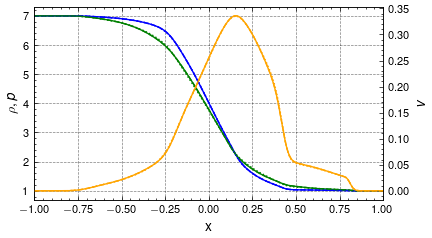

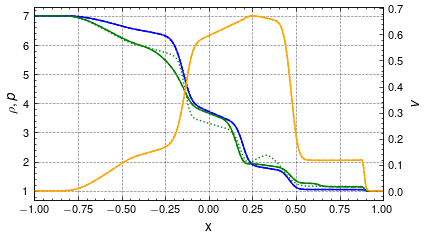

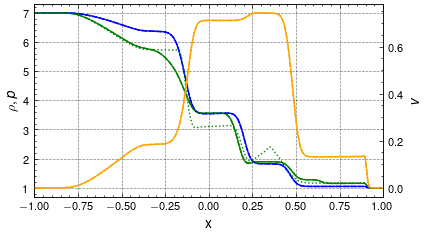

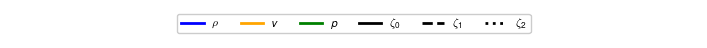

In [8]:
# Merging both
for Kn, source in zip(Knudsen, sources):
    fig, axs = plt.subplots(figsize=(6.0 * 3/4, 2.5))
    twx = axs.twinx()
    twx.grid(False)

    axs.set_xlim(-1, 1)
    axs.set_xlabel('x')
    axs.set_ylabel('$\\rho, p$')
    twx.set_ylabel('$v$')

    # Stable angles
    for i in range(n_angle_pairs - 1):
        solution_file = name(i, Kn, source)
        data = read_solution_file(solution_file)
        
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))
        
        time_query = 21 
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, U = sol["x"], sol["u"]

        rho = U[:, 0]
        v = U[:, 1] / U[:, 0]
        theta = 1 / (3 * rho) * (U[:, 2] + 2 * U[:, 3] - rho * v**2) 
        p = rho * theta

        axs.plot(x, rho, color=colors[0], linestyle=linestyles[i])
        twx.plot(x, v, color=colors[1], linestyle=linestyles[i])
        axs.plot(x, p, color=colors[2], linestyle=linestyles[i])
    # Legend and Layout
    axs.plot([], [], color=colors[0], lw=2, label='$\\rho$')
    axs.plot([], [], color=colors[1], lw=2, label='$v$')
    axs.plot([], [], color=colors[2], lw=2, label='$p$')
    [axs.plot([], [], color='black', linestyle=linestyles[i], lw=2, label=f'$\\zeta_{i}$') for i in range(n_angle_pairs-1)]

    # Note: tight_layout often crushes manual insets, so we use it carefully or skip it
    # fig.tight_layout() 
    fig.savefig(f'../out/Figures/1D3D/Merged_AnglePairs_Kn{Kn}_source_{source}.pdf', bbox_inches='tight')
    plt.show()

# To save JUST the legend as a separate file
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one of your existing axes
handles, labels = axs.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', ncol=7)
fig_leg.savefig('../out/Figures/1D3D/legend_horizontal.pdf')

### Eigenvalues

Eigenvalues: [-2.4494897427831615, -1.4491376746152846, -1.0000000000000207, -1.0871619035046803e-18, 2.6307300042173307e-17, 6.020146002672997e-17, 8.997358192559335e-17, 1.000000000000021, 1.4491376746152846, 2.449489742783165]
Eigenvalues: [-2.4494897427831615, -1.4491376746159783, -1.0000000000000224, -2.641026052406963e-18, 1.1414772260227168e-18, 7.755316201270294e-17, 1.157176166823809e-16, 1.0000000000000215, 1.4491376746159768, 2.449489742783164]
Eigenvalues: [-2.449489731322747, -1.0036390780448083, -0.9999994660518089, -3.9093351977010375e-17, 4.904782368031232e-19, 9.368072931044669e-17, 2.020992875921412e-16, 0.999999466051805, 1.003639078044811, 2.449489731322747]
Eigenvalues: [-2.449490872741498, -0.9999997661467456, -1.2098199703351574e-16, -6.243131867861777e-18, 5.263027318067975e-17, 1.8778069665943076e-16, 3.3306690738754696e-16, 3.3306690738754696e-16, 0.9999997661467461, 2.449490872741499]


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_84414/932589572.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


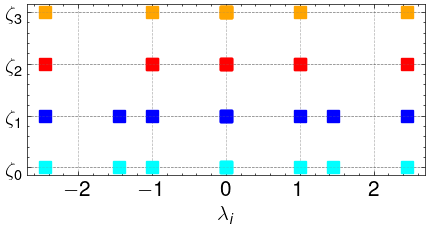

In [9]:
x_dest = -2.0

Kn = 1.0
eigenvalues = []
for anglepair in range(n_angle_pairs):
    file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'
    data = pd.read_csv(file(anglepair))

    x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
    lambda_values_string = data['eigenvalue'][x_idx]
    lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
    eigenvalues.append(lambda_values)

    print(f'Eigenvalues: {lambda_values}')

angles = [
    (eigenvalues[0], 'cyan', '$\\zeta_0$'),
    (eigenvalues[1], 'blue', '$\\zeta_1$'),
    (eigenvalues[2], 'red', '$\\zeta_2$'),
    (eigenvalues[3], 'orange', '$\\zeta_3$')
]

fig, axs = plt.subplots(figsize=(6.0 * 3/4, 2.5))

for i, (lambda_values, color, label) in enumerate(angles):
    # Plot the eigenvalues as points at height 'i'
    axs.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
    
    # Add a faint horizontal line to guide the eye for each category
    axs.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

axs.tick_params(axis='x', labelsize=15)
axs.set_yticks(range(len(angles)), [m[2] for m in angles], fontsize=15)

axs.set_xlabel('$\\lambda_i$', fontsize=15)
# axs.set_ylabel('Closure Model')
axs.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

fig.tight_layout()
fig.savefig('../out/Figures/1D3D/Eigenvalues_Equilibrium.pdf')
fig.show()

Eigenvalues: [-2.2681820312042973, -0.9540307872345508, -0.5348107541996868, 0.4554885180141355, 0.47359323988715496, 0.47359323988715496, 0.5665042245374995, 1.2378722610668045, 1.7210090003166967, 2.7562706063441937]
Eigenvalues: [-2.268103819784822, -0.9674696355828826, -0.5347537156802191, 0.46954254538228724, 0.47578431771216756, 0.47578431771216756, 0.5665218990226768, 1.2379031909540583, 1.7246688805917711, 2.7563066721149596]
Eigenvalues: [-2.2624527648414, -0.5818977418703045, -0.5320454495981588, 0.5661639730170426, 0.5845419714099525, 0.6043109611909343, 0.6043109611909343, 1.2380478417381044, 1.36932603018109, 2.755293153832441]
Eigenvalues: [-2.3677069765769083, -0.5203775680849438, -0.24370224711278518, 0.5105516901086126, 0.5441263142867305, 0.703290405270426, 1.1775202057133076, 1.3823446830490838, 1.3823446830490838, 3.068608831283387]


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_84414/11641429.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


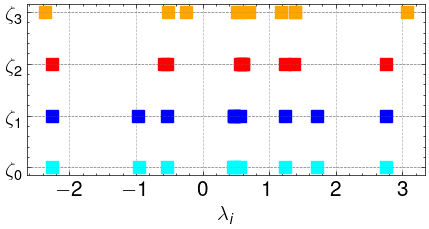

In [10]:
x_dest = 0.0

Kn = 1.0
eigenvalues = []
for anglepair in range(n_angle_pairs):
    file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'
    data = pd.read_csv(file(anglepair))

    x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
    lambda_values_string = data['eigenvalue'][x_idx]
    lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
    eigenvalues.append(lambda_values)

    print(f'Eigenvalues: {lambda_values}')

angles = [
    (eigenvalues[0], 'cyan', '$\\zeta_0$'),
    (eigenvalues[1], 'blue', '$\\zeta_1$'),
    (eigenvalues[2], 'red', '$\\zeta_2$'),
    (eigenvalues[3], 'orange', '$\\zeta_3$')
]

fig, axs = plt.subplots(figsize=(6.0 * 3/4, 2.5))

for i, (lambda_values, color, label) in enumerate(angles):
    # Plot the eigenvalues as points at height 'i'
    axs.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
    
    # Add a faint horizontal line to guide the eye for each category
    axs.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

axs.tick_params(axis='x', labelsize=15)
axs.set_yticks(range(len(angles)), [m[2] for m in angles], fontsize=15)

axs.set_xlabel('$\\lambda_i$', fontsize=15)
# axs.set_ylabel('Closure Model')
axs.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

fig.tight_layout()
fig.savefig('../out/Figures/1D3D/Eigenvalues_Shock.pdf')
fig.show()

# Check stabilization for Grad

In [11]:
closure = "Grad"
Kn = 1.0
source = "relaxation_source"

# Initial condition parameters for the Riemann problem
rho_L_vec = [4.0, 7.0, 15.0] #! 30.0 unstable for 1D1D and 1D3D
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0
rho_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

FileNotFoundError: [Errno 2] No such file or directory: '../out/1D3D/1D3D_angles/gram_solution_M4_closureGrad_Kn1.0_sourcerelaxation_source_T_end0.3_rho_L7.0_rho_R1.0_v_L10.0_v_L20.0_v_L30.0_v_R10.0_v_R20.0_v_R30.0_theta_L1.0_theta_R1.0_base_tree_level5_polydeg1_anglepairnumber0_cons.tsv'

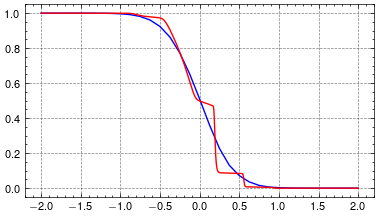

In [ ]:
fig, axs = plt.subplots(figsize=(6.0 * 3/4, 2.5))

name1D3D = lambda ho_L: f"../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{5}_polydeg{polydeg}_anglepairnumber{0}_cons.tsv"
name1D1D = lambda rho_L: f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L1}_v_R{v_R1}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

time_query = 21 # get last stored time step
for i, rho_L in enumerate(rho_L_vec):
    # 1D3D
    data_1D3D = read_solution_file(name1D3D(rho_L))

    times_1D3D = np.array([data_1D3D[ts]["t"] for ts in sorted(data_1D3D.keys())])
    timesteps_1D3D = np.array(sorted(data_1D3D.keys()))

    sol_1D3D = interpolate_solution(data_1D3D, time_query, times_1D3D, timesteps_1D3D)

    x_3d, U_3d = sol_1D3D["x"], sol_1D3D["u"]

    axs.plot(x_3d, (U_3d[:, 0] - rho_R) / (rho_L - rho_R), color='blue', linestyle=linestyles[i])

    # 1D1D
    if rho_L == 15.0:
        continue
    data_1D1D = read_solution_file(name1D1D(rho_L))

    times_1D1D = np.array([data_1D1D[ts]["t"] for ts in sorted(data_1D1D.keys())])
    timesteps_1D1D = np.array(sorted(data_1D1D.keys()))

    sol_1D1D = interpolate_solution(data_1D1D, time_query, times_1D1D, timesteps_1D1D)

    x_1d, U_1d = sol_1D1D["x"], sol_1D1D["u"]

    axs.plot(x_1d, (U_1d[:, 0] - rho_R) / (rho_L - rho_R), color='red', linestyle=linestyles[i])

axs.plot([], [], color='red', linestyle=linestyles[0], label='1D1D') 
axs.plot([], [], color='blue', linestyle=linestyles[0], label='1D3D') 
[axs.plot([], [], color='black', linestyle=linestyles[i], label=f'$\\rho_L={rho_L_vec[i]:g}$') for i in range(len(rho_L_vec))]
axs.set_xlim(0.0, 0.6)
axs.set_ylim(0.0, 0.5)
axs.set_xlabel('x')
axs.set_ylabel('$\\rho / \\rho_L$')
axs.legend()

fig.tight_layout()
fig.savefig("../out/Figures/1D3D/ShockTube_1D3D_Grad.pdf", bbox_inches='tight')
fig.show()